# スプリント区間抽出パラメータの調整

`src/pi_fsm/segments.py` の初期閾値(v_low=2.0, delta_v=2.0, window_s=1.0, t_max=10.0)で抽出した区間の数・長さ・v0分布・実際の速度プロファイルを確認し、必要なら閾値を調整する。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pi_fsm.data import load_match
from pi_fsm.preprocessing import add_velocity, exclude_goalkeepers
from pi_fsm.segments import SegmentParams, extract_sprints

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.family"] = "Hiragino Sans"

MATCH_ID = "J03WPY"
m = load_match(MATCH_ID)
df = exclude_goalkeepers(m.players)
df = add_velocity(df, m.frame_rate)
df.shape

(2924220, 11)

## デフォルト閾値での抽出

In [2]:
default_params = SegmentParams()
print(default_params)

segs = extract_sprints(df, m.frame_rate, match_id=MATCH_ID, params=default_params)
n_segments = segs["segment_id"].nunique()
n_players = df["player_id"].nunique()
match_minutes = df["t"].max() * df["period_id"].nunique() / 60

print(f"segments: {n_segments}")
print(f"players: {n_players}")
print(f"segments per player per match: {n_segments / n_players:.1f}")
print(f"segments per player per minute: {n_segments / n_players / match_minutes:.2f}")

v0_by_seg = segs.groupby("segment_id")["v0"].first()
display(v0_by_seg.describe())

SegmentParams(v_low=2.0, delta_v=2.0, window_s=1.0, t_max=10.0, decel_margin=1.0, decel_hold_s=0.5, max_frame_speed=12.0, min_duration_s=1.0, min_peak_speed=4.0)


segments: 1391
players: 29
segments per player per match: 48.0
segments per player per minute: 0.47


count    1391.000000
mean        1.047241
std         0.528869
min         0.000000
25%         0.621610
50%         1.034456
75%         1.490520
max         1.996722
Name: v0, dtype: float64

## 区間あたりの最高速度分布

区間内(rotated x,y)を有限差分して速さを再計算し、各区間のピーク速度を見る。「真のスプリント」ならピークが5〜7m/s程度に達するはず。閾値が緩すぎて低強度の加速まで拾っていないか確認する。

count    1391.000000
mean        5.795209
std         1.063507
min         4.257347
25%         4.949747
50%         5.550901
75%         6.403124
max         9.503289
dtype: float64

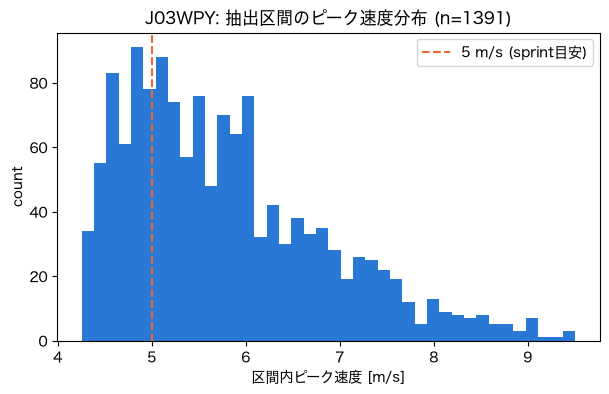

ピーク速度5m/s以上の割合: 73.3%
ピーク速度6m/s以上の割合: 36.4%


In [3]:
def peak_speed(g: pd.DataFrame) -> float:
    g = g.sort_values("t")
    dt = np.diff(g["t"].to_numpy())
    dx = np.diff(g["x"].to_numpy())
    dy = np.diff(g["y"].to_numpy())
    speed = np.hypot(dx, dy) / dt
    return speed.max()


peak_v = segs.groupby("segment_id").apply(peak_speed, include_groups=False)
display(peak_v.describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(peak_v, bins=40, color="#2a78d6")
ax.axvline(5.0, color="#eb6834", ls="--", label="5 m/s (sprint目安)")
ax.set_xlabel("区間内ピーク速度 [m/s]")
ax.set_ylabel("count")
ax.legend()
ax.set_title(f"{MATCH_ID}: 抽出区間のピーク速度分布 (n={len(peak_v)})")
plt.show()

print(f"ピーク速度5m/s以上の割合: {(peak_v >= 5.0).mean():.1%}")
print(f"ピーク速度6m/s以上の割合: {(peak_v >= 6.0).mean():.1%}")

## サンプル区間の速度プロファイル(目視確認)

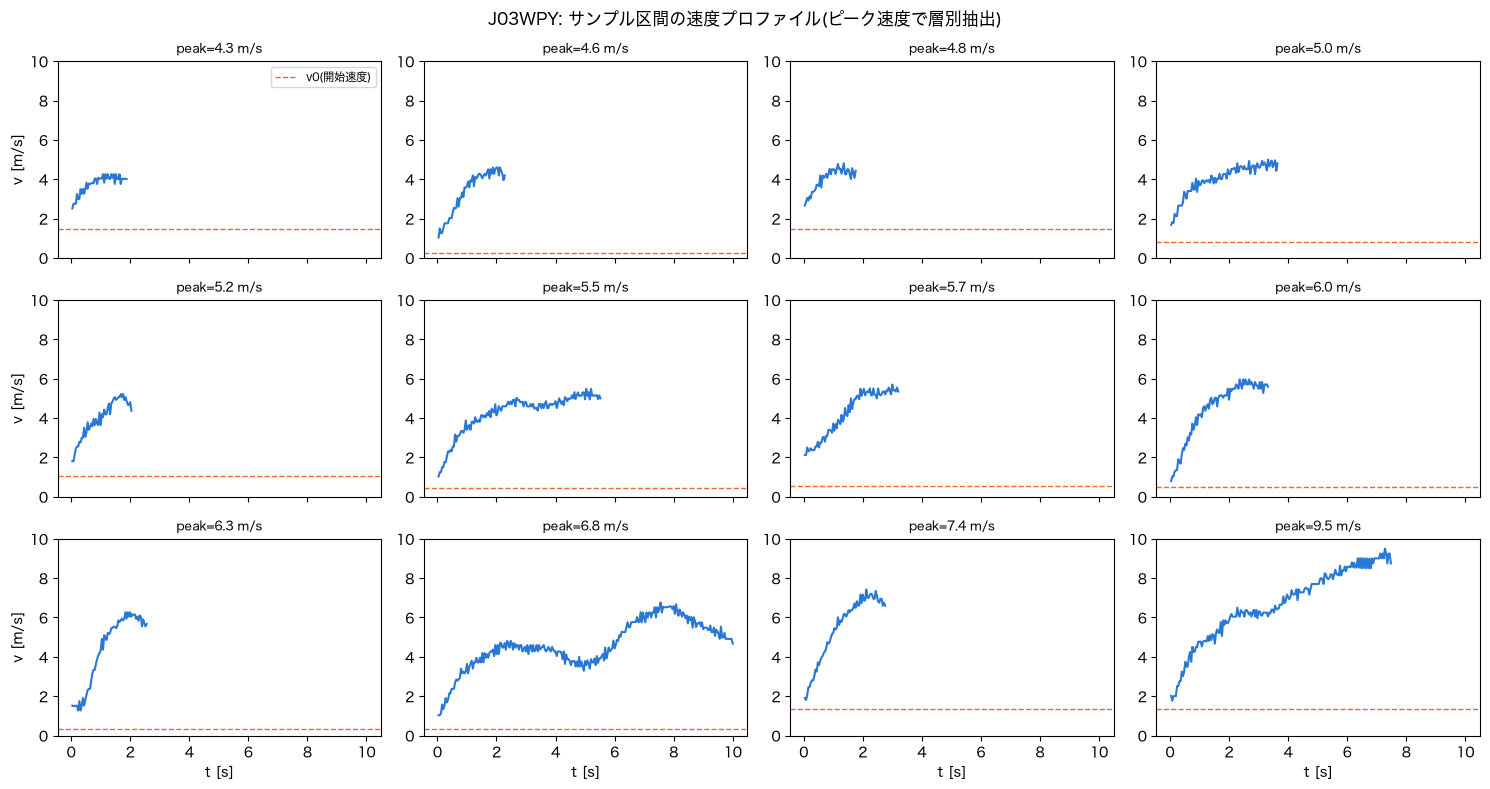

In [4]:
rng = np.random.default_rng(0)
# 高ピーク速度側から偏りなく見るため、ピーク速度で層別サンプリング
sample_ids = (
    peak_v.sort_values()
    .iloc[np.linspace(0, len(peak_v) - 1, 12).astype(int)]
    .index
)

fig, axes = plt.subplots(3, 4, figsize=(15, 8), sharex=True)
for ax, seg_id in zip(axes.flat, sample_ids):
    g = segs[segs["segment_id"] == seg_id].sort_values("t")
    dt = np.diff(g["t"].to_numpy())
    speed = np.hypot(np.diff(g["x"].to_numpy()), np.diff(g["y"].to_numpy())) / dt
    ax.plot(g["t"].to_numpy()[1:], speed, color="#2a78d6")
    ax.axhline(g["v0"].iloc[0], color="#eb6834", ls="--", lw=1, label="v0(開始速度)")
    ax.set_title(f"peak={speed.max():.1f} m/s", fontsize=9)
    ax.set_ylim(0, 10)
for ax in axes[-1]:
    ax.set_xlabel("t [s]")
for ax in axes[:, 0]:
    ax.set_ylabel("v [m/s]")
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"{MATCH_ID}: サンプル区間の速度プロファイル(ピーク速度で層別抽出)")
fig.tight_layout()
plt.show()

## 結論

初期閾値(固定10秒枠、フィルタなし)では以下の問題があった:
- 加速→減速→再加速が1区間に混在(固定長のため)
- 1フレームの位置飛びによる異常値(peak=1002m/s)が混入
- ピーク2〜4m/s程度の「ジョグ」レベルの弱い加速も大量に含まれる(区間の約4割)

`segments.py` に以下を追加して解消:
- **減速カット**: ピークからdecel_margin(1.0m/s)以上・decel_hold_s(0.5s)以上持続して落ちたらそこで区間を打ち切る
- **異常値除外**: 区間内フレーム間速度がmax_frame_speed(12m/s、物理的にありえない)を超えたら区間ごと破棄
- **最小ピーク速度フィルタ**: min_peak_speed(4m/s)未満はスプリントとみなさず破棄

最終パラメータ(`J03WPY`, 1試合): **1391区間**(選手あたり48区間/試合)、ピーク5m/s以上が73%。サンプルプロットも単一の滑らかな加速フェーズになっており、PINN学習用データとして妥当と判断。